# Introduction to Data Science 2026

# Week 5

## Exercise 1 | Privacy and data protection

First, look up the [European Data Protection Regulation](http://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32016R0679&from=en) (“GDPR”). Note that Articles 1-99 start on p. 32 of the document. We will refer to the articles and their parts by, e.g., “Art 6 (1) a) GDPR” which means Article 6 (“Lawfulness of processing”), first paragraph, item a in the GDPR.

1. Valid Consent?

    Find a service you use to which you have given *consent* for the processing of your personal data (Art 6 (1) a) GDPR). Have a look at the privacy notices, policies, or settings of this service.

    - Are the basic legal conditions for this consent in your opinion in line with the new requirements and conditions set by the GDPR?

    - You should provide an answer with justification based on the GDPR, where you refer to specific articles and paragraphs.

2. Your Right to Access your Personal Data

    You have the right to know if personal data about you is processed by a controller. You also have the right to get access to, for example, the processing purposes, the data categories, data transfers, and duration of storage.

    - Find the relevant parts in GDPR and study your rights as a “data subject”.

    - File a right-to-access request with a data processing service of your choosing. Describe the mechanism that is put in place by the service to enable you to exercise this right (if any).

    - Whether you get a response or not, think about how well your rights as a data subject are respected in practice. Your answer should again refer to specific articles and paragraphs of the GDPR.

3. Anonymisation & Pseudonymisation

    - What is the difference between anonymisation and pseudonymisation of personal data?

**Submit your findings in a PDF file, just a short report is enough.**

# 1. Valid Consent:
 **a)** Yes, YouTube asks for consent for processing data. Though technically the quality of service they provide does somewhat go down if you don't/can't consent. Namely, that an account allows for saving to playlists, subscribing to channels, getting notifications when new uploads happen. And, the personalized algorithm that caters to one's individual interests.
 **b)** If you set up say Google Pay, Google would need your information to do transactions with, so yes this is done.
 **c,d,e)** I do believe Google (technically Alphabet) as a whole does process data if their internal safety systems are tripped. E.g. If you Google something like "How to make a pipebomb" or similar, this info will be sent to your local authorities to deal with how they see fit. And, I think this holds true if you begin to ask about self-harm related questions, or at least Google's services (notably YouTube) will show some form of hotline number to call.
 **f)** Google and YouTube are huge in the business of advertising, selling and maintaining data, and targeting ADs. They're very clear that they do this, and especially the apps in the Play Store all greet you with a the whole advertising/data processing consent form thingy. The form is a bit dirty in the sense that it requires more effort to not consent to all data processing, than it takes to just accept all. They've also been at the center of the whole advertising and processing data of children. Which, honestly they probably still knowingly do, but just pretend they don't to comply.


# 2. Your Right to Access your Personal Data
- Google takeout already allows one to take a bunch of their data to go easily.
- There's also a Data Access Request Form, that gives you all of the data about you that Google has stored. The form is straight forward enough, email, country of residence, Google product selection, and state what data one is seeking.
- Each Alphabet service (Google, YouTube, etc.) appear to have a removal request for data as well.
- Eh, I have no doubt Google and YouTube (and every other sizeable company) on the surface have their documentation, especially the legal ones in order and GDPR compliant. It's always what they do secretly behind closed doors that's uncertain. They've probably figured out countless loopholes around GDPR issues, and only comply as much as they're forced to.

# 3. Anonymisation & Pseudonymisation
- Anonymization removes all identifying information of an individual from the data. Pseudonymization on the other hand keeps the data mostly intact, just swapping out the direct identifiers with some random ones. Anonymized data can't be reverse engineered directly to map it back to an individual, pseudo has a possibility.

## Exercise 2 | Fairness-aware AI

This template generates data about the working hours and salaries of n=5000 people. The salary equals 100 x working hours plus/minus normal distributed noise. If you run the template, it produces an _hours_ vs _monthly salary_ scatter plot with gender=0 (men) in orange and gender=1 (women) in orange. The plot includes a trend line for each group, and an overall trend line for all data combined (in red). 

A linear regression model (see the next code cell) that only includes the working hours as a covariate *without* the protected characteristic (gender) should have slope close to 100.0.

In [1]:
#Most of this I did myself with Gemini helping with checking for correctness

%matplotlib inline
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### Simulating the data

In [128]:
#Original data

#sample size n
n = 5000

# gender
gen = np.random.binomial(1, 0.5, size=n)

# work hours
hrs = np.random.binomial(60, 0.5, size=n)

# salary = 100 * hours + noise (std.deviation 10)
sal = hrs * np.random.normal(100, 10, size=n) 

# create a nice data frame
data = pd.DataFrame({"Gender": gen, "Hours": hrs, "Salary": sal})

In [129]:
#Salary discrimination
# salary = 100 * hours + noise (std.deviation 10)
sal_sal = sal - (gen == 1) * 200

# create a nice data frame
data_sal_discrimination = pd.DataFrame({"Gender": gen, "Hours": hrs, "Salary": sal_sal})


In [130]:
#Working hour diff

hrs_men = np.random.binomial(60, 0.55, size=n)
hrs_women = np.random.binomial(60, 0.45, size=n)
hrs_work = np.where(gen == 1, hrs_women, hrs_men)

# salary = 100 * hours + noise (std.deviation 10)
sal_work = hrs_work * np.random.normal(100, 10, size=n) 

# create a nice data frame
data_work_hour = pd.DataFrame({"Gender": gen, "Hours": hrs_work, "Salary": sal_work})

In [131]:
#salary discrimination, working hour diff
sal_sal_work = sal_work - (gen == 1) * 200

# create a nice data frame
data_sal_work = pd.DataFrame({"Gender": gen, "Hours": hrs_work, "Salary": sal_sal_work})



### Scatterplot of the simulated data
Women samples (gender = 1) are shown with blue, men samples (gender = 0) are shown in orange.
Blue and orange lines are the trend lines of each group accordingly.
The overall trend line is shown in red.

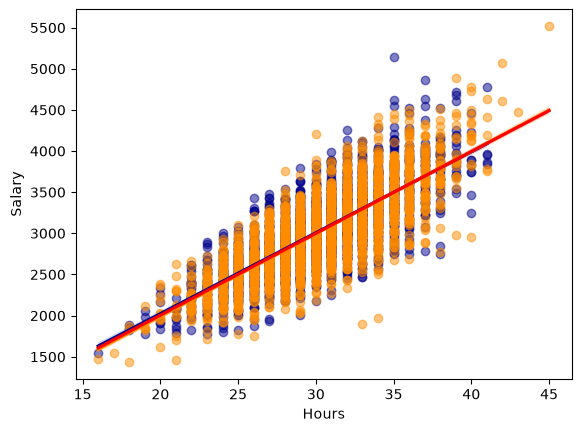

In [132]:
#original
sns.regplot(x="Hours", y="Salary", data=data[data["Gender"]==1], color="darkBlue", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data[data["Gender"]==0], color="darkOrange", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data, marker="None", color="red")

plt.show()

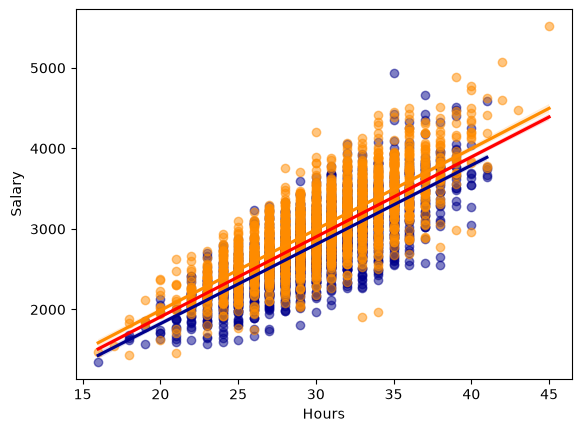

In [133]:
#sal discrimination

sns.regplot(x="Hours", y="Salary", data=data_sal_discrimination[data["Gender"]==1], color="darkBlue", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data_sal_discrimination[data["Gender"]==0], color="darkOrange", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data_sal_discrimination, marker="None", color="red")

plt.show()

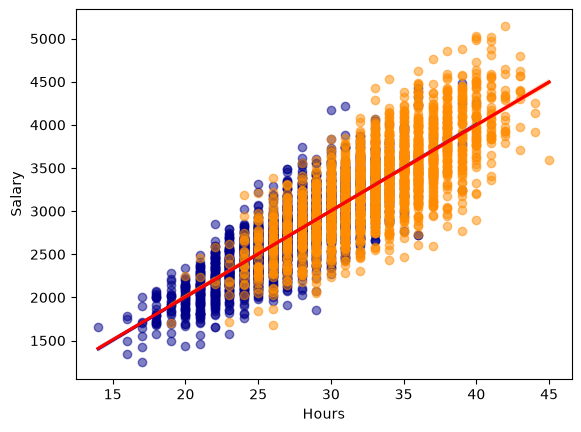

In [134]:
#work hour

sns.regplot(x="Hours", y="Salary", data=data_work_hour[data["Gender"]==1], color="darkBlue", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data_work_hour[data["Gender"]==0], color="darkOrange", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data_work_hour, marker="None", color="red")

plt.show()

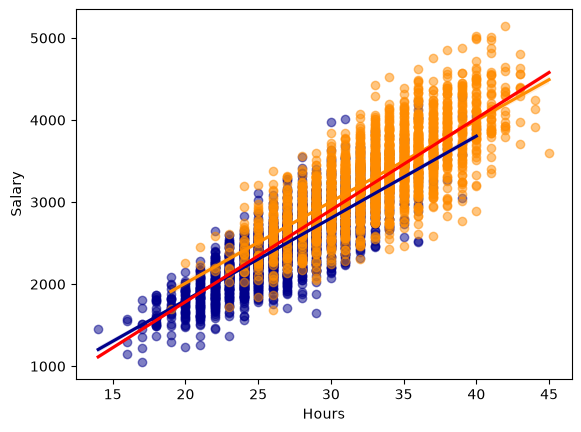

In [135]:
#salary discrimination, work hour diff

sns.regplot(x="Hours", y="Salary", data=data_sal_work[data["Gender"]==1], color="darkBlue", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data_sal_work[data["Gender"]==0], color="darkOrange", scatter_kws={'alpha':0.5})

sns.regplot(x="Hours", y="Salary", data=data_sal_work, marker="None", color="red")

plt.show()

### Linear regression
Learn the overall regression model, which is what an algorithm with no access to the gender ("protected characteristic") would learn from the data.

In [106]:
reg = LinearRegression().fit(hrs.reshape(-1,1), sal.reshape(-1,1))
reg_work = LinearRegression().fit(hrs_work.reshape(-1,1), sal.reshape(-1,1))
# print out the slope: it should be close to 100.0 without learning the 'protected characteristic' (gender)
print("slope: %.1f" % reg.coef_[0][0], reg_work.coef_[0][0])

slope: 100.7 -0.6290053983997393


In [136]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Dictionary holding all four dataframes
datasets = {
    "Original": data,
    "Scenario (a) Direct": data_sal_discrimination,
    "Scenario (b) Hours": data_work_hour,
    "Scenario (c) Combined": data_sal_work,
}

# Run OLS model: Salary ~ Hours for each scenario
for name, df in datasets.items():
    model = smf.ols("Salary ~ Hours", data=df).fit()
    slope = model.params["Hours"]
    intercept = model.params["Intercept"]
    print(
        f"{name:25s} | Slope (per hour): {slope:6.2f} | Intercept: {intercept:8.2f}"
    )

Original                  | Slope (per hour):  99.41 | Intercept:    16.99
Scenario (a) Direct       | Slope (per hour):  99.31 | Intercept:   -79.10
Scenario (b) Hours        | Slope (per hour):  99.61 | Intercept:    14.72
Scenario (c) Combined     | Slope (per hour): 111.79 | Intercept:  -451.15


In [137]:
import statsmodels.api as sm

# Prepare features (Hours) and the protected characteristic (Gender)
X = data_sal_work[["Hours", "Gender"]]
X = sm.add_constant(X)  # Adds intercept beta_0
y = data_sal_work["Salary"]

# Fit Multiple Linear Regression
model_c = sm.OLS(y, X).fit()
print(model_c.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     8220.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:19:04   Log-Likelihood:                -35710.
No. Observations:                5000   AIC:                         7.143e+04
Df Residuals:                    4997   BIC:                         7.145e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7136     36.812      0.373      0.7

# Results

1. The slope changes only in the salary discrimination + working hour difference scenario.
2. I had no clue on this and had to ask Gemini. Turns out the answer is that the protected characteristic is Gender, and that including it uncovers the indirect discrimination. Bringing the hours back to normal, and uncovering the ~ -200e pay gap.

### Task

Now edit the code to simulate each of the following scenarios:

a) the salary of women is reduced by 200 euros ("direct discrimination")

b) the working hours of men are binomially distributed with parameters (60, 0.55) while the working hours of women are binomially distributed with parameters (60, 0.45), no changes in per-hour salary ("no discrimination")

c) both of the above changes at the same time ("indirect discrimination")

You should be able to demonstrate that the slope of the linear regression model is only changed in one of these scenarios.

Based on this experiment, answer the following questions:
1. In which of the scenarios the slope (coefficient) of the regression model changes?
2. How could you model the data in a way that enables you to detect indirect discrimination? _Hint_: Should you include the protected characteristic in the model or not?

To answer the second question, demonstrate your solution by building a regression model and interpreting the estimated coefficients.

**Submit this exercise by submitting your code and your answers to the above questions on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**